<a href="https://colab.research.google.com/github/jerinSabrina/Time_Series_project/blob/main/Data_Mining_Cup_Course/1_DMC_Sabrina_RandomForest_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Read the dataset and inner join the masse column with fraction column 1 to 14


In [ ]:
import pandas as pd
import numpy as np

input_df = pd.read_csv("eingangsbandwaage_studenten.csv")
target_df = pd.read_csv("ballengewichte_studenten.csv")

input_df["Zeitstempel"] = pd.to_datetime(input_df["Zeitstempel"])
target_df["Datum"] = pd.to_datetime(target_df["Datum"])

input_df = input_df.rename(columns={"Zeitstempel": "date"})
target_df = target_df.rename(columns={"Datum": "date"})

df = pd.merge(
    target_df,
    input_df,
    on="date",
    how="inner"
)

df = df.sort_values("date").reset_index(drop=True)

display(df.head())
print(df.shape)

,date,1,2,3,4,5,6,7,8,9,10,11,12,13,14,Masse
0,2020-03-02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.291561
1,2020-03-12,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.638127
2,2020-03-18,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.320958
3,2020-03-19,0.174107,0.162197,0.045873,0.143295,0.094573,0.030079,0.058928,0.080483,0.196569,0.013896,0.000000,0.0,0.00000,0.0,0.457763
4,2020-03-20,0.215771,0.207817,0.049766,0.105373,0.072167,0.016228,0.060927,0.059821,0.117118,0.000000,0.006941,0.0,0.08807,0.0,0.544210


(1546, 16)


In [ ]:
min_date = df['date'].min()
max_date = df['date'].max()

print(f"The date range of the dataset is from {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}.")

The date range of the dataset is from 2020-03-02 to 2024-12-31.


###Features Selection

In [ ]:
#target column
target_col = "1"


#Manually select the time based column feature to build random forest
# Clean Masse
df["Masse_clean"] = df["Masse"].clip(lower=0)

# Create lag features
lags = [1, 2, 7, 14]

for lag in lags:
    df[f"Masse_lag_{lag}"] = df["Masse_clean"].shift(lag)
    df[f"target_1_lag_{lag}"] = df[target_col].shift(lag)

# Calendar feature
df["month"] = df["date"].dt.month
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Final feature list
feature_cols = [
    "Masse_clean",
    "Masse_lag_1",
    "Masse_lag_2",
    "Masse_lag_7",
    "Masse_lag_14",
    "target_1_lag_1",
    "target_1_lag_2",
    "target_1_lag_7",
    "target_1_lag_14",
    "month_sin",
    "month_cos"
]

model_df = df.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)

X = model_df[feature_cols]
y = model_df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

display(model_df[["date", target_col] + feature_cols].head())

X shape: (1532, 11)
y shape: (1532,)


,date,1,Masse_clean,Masse_lag_1,Masse_lag_2,Masse_lag_7,Masse_lag_14,target_1_lag_1,target_1_lag_2,target_1_lag_7,target_1_lag_14,month_sin,month_cos
0,2020-03-30,0.254328,0.562966,0.676445,0.681476,0.599744,0.291561,0.135348,0.228954,0.205198,0.000000,1.000000,6.123234e-17
1,2020-03-31,0.121960,0.524558,0.562966,0.676445,0.599833,0.638127,0.254328,0.135348,0.185218,1.000000,1.000000,6.123234e-17
2,2020-04-01,0.204284,0.469459,0.524558,0.562966,0.584717,0.320958,0.121960,0.254328,0.153014,1.000000,0.866025,-5.000000e-01
3,2020-04-02,0.128373,0.410352,0.469459,0.524558,0.517333,0.457763,0.204284,0.121960,0.216507,0.174107,0.866025,-5.000000e-01
4,2020-04-03,0.186749,0.572191,0.410352,0.469459,0.576594,0.544210,0.128373,0.204284,0.150809,0.215771,0.866025,-5.000000e-01


In [ ]:
##define data range

train_df = model_df[
    (model_df["date"] >= "2020-01-01") &
    (model_df["date"] <= "2023-12-31")
].copy()

future_2024_df = model_df[
    (model_df["date"] >= "2024-01-01") &
    (model_df["date"] <= "2024-12-31")
].copy()

print("Train range:", train_df["date"].min(), "to", train_df["date"].max())
print("2024 range:", future_2024_df["date"].min(), "to", future_2024_df["date"].max())
print("Train rows:", len(train_df))
print("2024 rows:", len(future_2024_df))

Train range: 2020-03-30 00:00:00 to 2023-12-30 00:00:00
2024 range: 2024-01-02 00:00:00 to 2024-12-31 00:00:00
Train rows: 1184
2024 rows: 348


In [ ]:

### Define model and horizon
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

models = {
    "Dummy Mean": DummyRegressor(strategy="mean"),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
}

,Evaluation,Horizon,Model,MAE,RMSE,Train Start,Train End,Test Start,Test End
2,Without CV - 2024 Holdout,1 week,Random Forest,0.022014,0.025972,2020-03-30,2023-12-30,2024-01-02,2024-01-08
0,Without CV - 2024 Holdout,1 week,Naive lag-1,0.024192,0.027680,2020-03-30,2023-12-30,2024-01-02,2024-01-08
1,Without CV - 2024 Holdout,1 week,Dummy Mean,0.044557,0.052506,2020-03-30,2023-12-30,2024-01-02,2024-01-08
3,Without CV - 2024 Holdout,2 weeks,Naive lag-1,0.017981,0.022084,2020-03-30,2023-12-30,2024-01-02,2024-01-16
5,Without CV - 2024 Holdout,2 weeks,Random Forest,0.030595,0.034410,2020-03-30,2023-12-30,2024-01-02,2024-01-16
4,Without CV - 2024 Holdout,2 weeks,Dummy Mean,0.057079,0.063431,2020-03-30,2023-12-30,2024-01-02,2024-01-16


In [ ]:
from sklearn.model_selection import TimeSeriesSplit

cv_results = []

for horizon_name, horizon_size in horizons.items():

    tscv = TimeSeriesSplit(
        n_splits=5,
        test_size=horizon_size
    )

    for fold, (train_idx, test_idx) in enumerate(tscv.split(train_df), start=1):

        cv_train_df = train_df.iloc[train_idx].copy()
        cv_test_df = train_df.iloc[test_idx].copy()

        X_cv_train = cv_train_df[feature_cols]
        y_cv_train = cv_train_df[target_col]

        X_cv_test = cv_test_df[feature_cols]
        y_cv_test = cv_test_df[target_col]

        # Naive baseline
        naive_pred = cv_test_df["target_1_lag_1"].values

        cv_results.append({
            "Evaluation": "CV inside 2020-2023",
            "Horizon": horizon_name,
            "Model": "Naive lag-1",
            "Fold": fold,
            "MAE": mean_absolute_error(y_cv_test, naive_pred),
            "RMSE": calculate_rmse(y_cv_test, naive_pred),
            "Train Start": cv_train_df["date"].min(),
            "Train End": cv_train_df["date"].max(),
            "Test Start": cv_test_df["date"].min(),
            "Test End": cv_test_df["date"].max()
        })

        for model_name, model in models.items():

            model.fit(X_cv_train, y_cv_train)

            y_cv_pred = model.predict(X_cv_test)
            y_cv_pred = np.clip(y_cv_pred, 0, 1)

            cv_results.append({
                "Evaluation": "CV inside 2020-2023",
                "Horizon": horizon_name,
                "Model": model_name,
                "Fold": fold,
                "MAE": mean_absolute_error(y_cv_test, y_cv_pred),
                "RMSE": calculate_rmse(y_cv_test, y_cv_pred),
                "Train Start": cv_train_df["date"].min(),
                "Train End": cv_train_df["date"].max(),
                "Test Start": cv_test_df["date"].min(),
                "Test End": cv_test_df["date"].max()
            })

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df)

,Evaluation,Horizon,Model,Fold,MAE,RMSE,Train Start,Train End,Test Start,Test End
0,CV inside 2020-2023,1 week,Naive lag-1,1,0.063001,0.104210,2020-03-30,2023-11-20,2023-11-21,2023-11-27
1,CV inside 2020-2023,1 week,Dummy Mean,1,0.035277,0.068240,2020-03-30,2023-11-20,2023-11-21,2023-11-27
2,CV inside 2020-2023,1 week,Random Forest,1,0.034358,0.063733,2020-03-30,2023-11-20,2023-11-21,2023-11-27
3,CV inside 2020-2023,1 week,Naive lag-1,2,0.012067,0.015743,2020-03-30,2023-11-27,2023-11-28,2023-12-05
4,CV inside 2020-2023,1 week,Dummy Mean,2,0.023605,0.025453,2020-03-30,2023-11-27,2023-11-28,2023-12-05
5,CV inside 2020-2023,1 week,Random Forest,2,0.022174,0.026478,2020-03-30,2023-11-27,2023-11-28,2023-12-05
6,CV inside 2020-2023,1 week,Naive lag-1,3,0.023522,0.026726,2020-03-30,2023-12-05,2023-12-06,2023-12-13
7,CV inside 2020-2023,1 week,Dummy Mean,3,0.021073,0.025325,2020-03-30,2023-12-05,2023-12-06,2023-12-13
8,CV inside 2020-2023,1 week,Random Forest,3,0.026157,0.030853,2020-03-30,2023-12-05,2023-12-06,2023-12-13
9,CV inside 2020-2023,1 week,Naive lag-1,4,0.041285,0.060673,2020-03-30,2023-12-13,2023-12-14,2023-12-20


In [ ]:
cv_summary_df = (
    cv_results_df
    .groupby(["Evaluation", "Horizon", "Model"])[["MAE", "RMSE"]]
    .mean()
    .reset_index()
    .sort_values(["Horizon", "MAE"])
)

display(cv_summary_df)

,Evaluation,Horizon,Model,MAE,RMSE
2,CV inside 2020-2023,1 week,Random Forest,0.031616,0.046248
1,CV inside 2020-2023,1 week,Naive lag-1,0.035860,0.053199
0,CV inside 2020-2023,1 week,Dummy Mean,0.038105,0.050897
5,CV inside 2020-2023,2 weeks,Random Forest,0.038198,0.059718
4,CV inside 2020-2023,2 weeks,Naive lag-1,0.047422,0.070635
3,CV inside 2020-2023,2 weeks,Dummy Mean,0.050521,0.069847


In [ ]:
holdout_summary_df = holdout_results_df[[
    "Evaluation", "Horizon", "Model", "MAE", "RMSE"
]]

final_comparison_df = pd.concat(
    [cv_summary_df, holdout_summary_df],
    ignore_index=True
)

final_comparison_df = final_comparison_df.sort_values(
    ["Horizon", "Evaluation", "MAE"]
)

display(final_comparison_df)

,Evaluation,Horizon,Model,MAE,RMSE
0,CV inside 2020-2023,1 week,Random Forest,0.031616,0.046248
1,CV inside 2020-2023,1 week,Naive lag-1,0.035860,0.053199
2,CV inside 2020-2023,1 week,Dummy Mean,0.038105,0.050897
8,Without CV - 2024 Holdout,1 week,Random Forest,0.022014,0.025972
6,Without CV - 2024 Holdout,1 week,Naive lag-1,0.024192,0.027680
7,Without CV - 2024 Holdout,1 week,Dummy Mean,0.044557,0.052506
3,CV inside 2020-2023,2 weeks,Random Forest,0.038198,0.059718
4,CV inside 2020-2023,2 weeks,Naive lag-1,0.047422,0.070635
5,CV inside 2020-2023,2 weeks,Dummy Mean,0.050521,0.069847
9,Without CV - 2024 Holdout,2 weeks,Naive lag-1,0.017981,0.022084


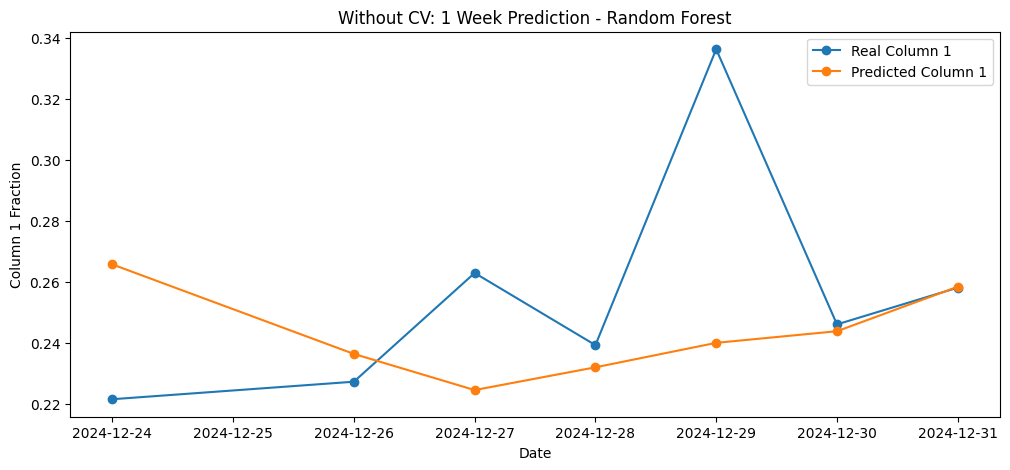

,date,Masse,real_col_1,predicted_col_1,error,absolute_error,Horizon,Model
1525,2024-12-24,0.820967,0.221623,0.265843,-0.044221,0.044221,1 week,Random Forest
1526,2024-12-26,0.747486,0.227366,0.236478,-0.009112,0.009112,1 week,Random Forest
1527,2024-12-27,0.893760,0.263026,0.224627,0.038398,0.038398,1 week,Random Forest
1528,2024-12-28,0.775929,0.239367,0.232091,0.007276,0.007276,1 week,Random Forest
1529,2024-12-29,0.629213,0.336419,0.240116,0.096304,0.096304,1 week,Random Forest
1530,2024-12-30,0.862853,0.246167,0.243930,0.002237,0.002237,1 week,Random Forest
1531,2024-12-31,0.796738,0.258223,0.258516,-0.000293,0.000293,1 week,Random Forest


In [ ]:
import matplotlib.pyplot as plt

plot_df = no_cv_predictions[("1 week", "Random Forest")]

plt.figure(figsize=(12, 5))

plt.plot(
    plot_df["date"],
    plot_df["real_col_1"],
    marker="o",
    label="Real Column 1"
)

plt.plot(
    plot_df["date"],
    plot_df["predicted_col_1"],
    marker="o",
    label="Predicted Column 1"
)

plt.xlabel("Date")
plt.ylabel("Column 1 Fraction")
plt.title("Without CV: 1 Week Prediction - Random Forest")
plt.legend()
plt.show()

display(plot_df)

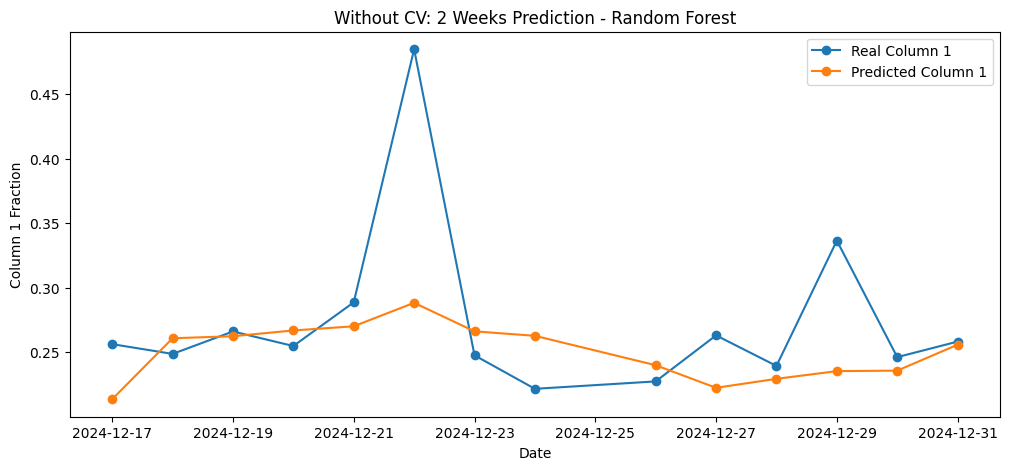

,date,Masse,real_col_1,predicted_col_1,error,absolute_error,Horizon,Model
1518,2024-12-17,0.930248,0.256227,0.213570,0.042657,0.042657,2 weeks,Random Forest
1519,2024-12-18,0.864200,0.248665,0.260792,-0.012126,0.012126,2 weeks,Random Forest
1520,2024-12-19,0.873245,0.266036,0.262365,0.003671,0.003671,2 weeks,Random Forest
1521,2024-12-20,0.858065,0.254787,0.266836,-0.012048,0.012048,2 weeks,Random Forest
1522,2024-12-21,0.812322,0.288602,0.270056,0.018546,0.018546,2 weeks,Random Forest
1523,2024-12-22,0.814844,0.484654,0.288254,0.196400,0.196400,2 weeks,Random Forest
1524,2024-12-23,0.861805,0.247564,0.266151,-0.018587,0.018587,2 weeks,Random Forest
1525,2024-12-24,0.820967,0.221623,0.262682,-0.041059,0.041059,2 weeks,Random Forest
1526,2024-12-26,0.747486,0.227366,0.239909,-0.012543,0.012543,2 weeks,Random Forest
1527,2024-12-27,0.893760,0.263026,0.222412,0.040614,0.040614,2 weeks,Random Forest


In [ ]:
plot_df = no_cv_predictions[("2 weeks", "Random Forest")]

plt.figure(figsize=(12, 5))

plt.plot(
    plot_df["date"],
    plot_df["real_col_1"],
    marker="o",
    label="Real Column 1"
)

plt.plot(
    plot_df["date"],
    plot_df["predicted_col_1"],
    marker="o",
    label="Predicted Column 1"
)

plt.xlabel("Date")
plt.ylabel("Column 1 Fraction")
plt.title("Without CV: 2 Weeks Prediction - Random Forest")
plt.legend()
plt.show()

display(plot_df)

# Simple Random Forest

In [ ]:

from sklearn.model_selection import TimeSeriesSplit
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

models = {
    "Dummy Mean": DummyRegressor(strategy="mean"),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
}

tscv = TimeSeriesSplit(n_splits=5)

cv_results = []

for model_name, model in models.items():

    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_pred = np.clip(y_pred, 0, 1)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        fold_results.append({
            "model": model_name,
            "fold": fold,
            "train_size": len(train_idx),
            "test_size": len(test_idx),
            "MAE": mae,
            "RMSE": rmse
        })

    cv_results.extend(fold_results)

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df)

summary_results = (
    cv_results_df
    .groupby("model")[["MAE", "RMSE"]]
    .mean()
    .reset_index()
    .sort_values("MAE")
)

display(summary_results)

,model,fold,train_size,test_size,MAE,RMSE
0,Dummy Mean,1,257,255,0.052425,0.076508
1,Dummy Mean,2,512,255,0.024670,0.039744
2,Dummy Mean,3,767,255,0.023781,0.039636
3,Dummy Mean,4,1022,255,0.043084,0.061580
4,Dummy Mean,5,1277,255,0.055736,0.087735
5,Random Forest,1,257,255,0.052471,0.080407
6,Random Forest,2,512,255,0.025343,0.041105
7,Random Forest,3,767,255,0.028354,0.045498
8,Random Forest,4,1022,255,0.034194,0.054609
9,Random Forest,5,1277,255,0.036381,0.071344


,model,MAE,RMSE
1,Random Forest,0.035349,0.058593
0,Dummy Mean,0.039939,0.061041


In [ ]:
best_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

prediction_parts = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    best_model.fit(X_train, y_train)

    y_pred = best_model.predict(X_test)
    y_pred = np.clip(y_pred, 0, 1)

    fold_prediction = model_df.iloc[test_idx][["date", "Masse", target_col]].copy()
    fold_prediction = fold_prediction.rename(columns={target_col: "real_col_1"})

    fold_prediction["predicted_col_1"] = y_pred
    fold_prediction["error"] = fold_prediction["real_col_1"] - fold_prediction["predicted_col_1"]
    fold_prediction["absolute_error"] = fold_prediction["error"].abs()
    fold_prediction["fold"] = fold

    prediction_parts.append(fold_prediction)

real_vs_prediction_df = pd.concat(prediction_parts).reset_index(drop=True)

display(real_vs_prediction_df.head())
display(real_vs_prediction_df.tail())

,date,Masse,real_col_1,predicted_col_1,error,absolute_error,fold
0,2021-01-17,0.054322,0.578123,0.251702,0.326421,0.326421,1
1,2021-01-18,0.674047,0.233372,0.215242,0.018130,0.018130,1
2,2021-01-19,0.683132,0.213751,0.216863,-0.003112,0.003112,1
3,2021-01-20,0.634418,0.180643,0.203704,-0.023060,0.023060,1
4,2021-01-21,0.634000,0.163063,0.191867,-0.028805,0.028805,1


,date,Masse,real_col_1,predicted_col_1,error,absolute_error,fold
1270,2024-12-27,0.893760,0.263026,0.218900,0.044126,0.044126,5
1271,2024-12-28,0.775929,0.239367,0.233278,0.006089,0.006089,5
1272,2024-12-29,0.629213,0.336419,0.231828,0.104591,0.104591,5
1273,2024-12-30,0.862853,0.246167,0.230731,0.015436,0.015436,5
1274,2024-12-31,0.796738,0.258223,0.238947,0.019276,0.019276,5


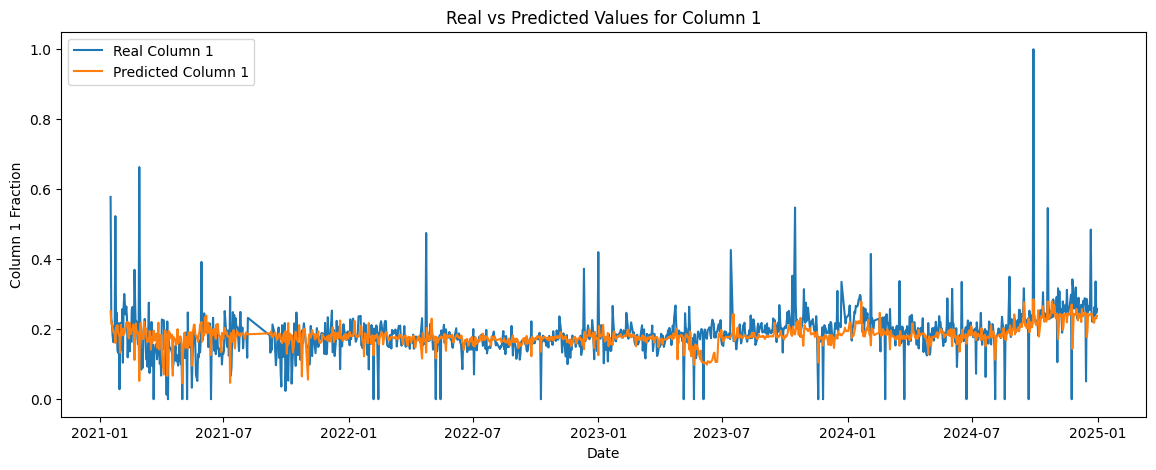

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    real_vs_prediction_df["date"],
    real_vs_prediction_df["real_col_1"],
    label="Real Column 1"
)

plt.plot(
    real_vs_prediction_df["date"],
    real_vs_prediction_df["predicted_col_1"],
    label="Predicted Column 1"
)

plt.xlabel("Date")
plt.ylabel("Column 1 Fraction")
plt.title("Real vs Predicted Values for Column 1")
plt.legend()
plt.show()